# Minimizing the 2-D Ackley Function Using a Genetic Algorithm

**Course:** Machine Learning  
**Assignment:** Genetic Algorithm (GA) optimization   
**Group members:** 2107005 , 2107007 , 2107030 , 2107043 , 2107056

---

## 1. Objective

The goal is to use a **Genetic Algorithm** to find the global minimum of the two-dimensional Ackley function. The search is limited to:

$$-5 \le x_1 \le 5, \qquad -5 \le x_2 \le 5.$$

The known global minimum is:

$$\mathbf{x}^*=(0,0), \qquad f(\mathbf{x}^*)=0.$$

Because a GA is stochastic (random), the numerical answer may be extremely close to zero instead of exactly zero.

## 2. Ackley Function

For $n$ dimensions, the Ackley function is

$$
f(\mathbf{x})=-a\exp\left(-b\sqrt{\frac{1}{n}\sum_{i=1}^{n}x_i^2}\right)
-\exp\left(\frac{1}{n}\sum_{i=1}^{n}\cos(cx_i)\right)+a+e,
$$

where the recommended constants are $a=20$, $b=0.2$, and $c=2\pi$.

For this assignment, $n=2$. Therefore, each chromosome is a real-valued vector

$$[x_1,x_2].$$

The function is **multimodal**, meaning it has many local minima. This makes it a useful benchmark for testing whether an optimization algorithm can avoid getting trapped away from the global solution.

In [6]:
# Import the libraries used in this notebook.
import warnings
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

# Make NumPy output easier to read and plots consistent.
np.set_printoptions(precision=8, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")
warnings.filterwarnings("ignore", message="FigureCanvasAgg is non-interactive")

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. GA Settings

The settings below follow the assignment instructions.

| Setting | Value | Meaning |
|---|---:|---|
| Encoding | Real/value encoding | One chromosome is $[x_1,x_2]$ |
| Search range | $[-5,5]$ | Used for both variables |
| Population size | 50 | Number of candidate solutions |
| Maximum generations | 100 | Maximum number of iterations |
| Crossover probability | 0.80 | 80% chance for each parent pair |
| Mutation probability | 0.05 | 5% chance for each gene |
| Elites | 1 | Preserve the best solution |
| Selection | Roulette wheel | Better solutions are more likely to be parents |
| Crossover | One-point | For two genes, cut between $x_1$ and $x_2$ |
| Mutation | Gaussian value change | Add a small random value, then clip to the range |

We use both a maximum-generation limit and a target-fitness stopping rule. This prevents an endless loop while allowing an early stop if a sufficiently accurate solution is found.

In [7]:
@dataclass
class GAConfig:
    """All GA settings in one place so they are easy to change."""

    population_size: int = 50
    dimensions: int = 2
    lower_bound: float = -5.0
    upper_bound: float = 5.0
    max_generations: int = 100
    crossover_probability: float = 0.80
    mutation_probability: float = 0.05
    elite_count: int = 1
    initial_mutation_sigma: float = 0.50
    minimum_mutation_sigma: float = 1e-5
    target_fitness: float = 1e-10
    seed: int = 42


config = GAConfig()
print(config)

GAConfig(population_size=50, dimensions=2, lower_bound=-5.0, upper_bound=5.0, max_generations=100, crossover_probability=0.8, mutation_probability=0.05, elite_count=1, initial_mutation_sigma=0.5, minimum_mutation_sigma=1e-05, target_fitness=1e-10, seed=42)


## 4. Modular Implementation

Each important GA operation is written as a separate function. This makes the program easier to read, test, reuse, and explain.

In [8]:
def ackley(x, a=20.0, b=0.2, c=2 * np.pi):
    """Return Ackley objective value(s).

    Parameters
    ----------
    x : array-like
        A single chromosome with shape (2,), or a full population with
        shape (population_size, 2).

    Returns
    -------
    float or ndarray
        Ackley value(s). Smaller is better.
    """
    x = np.asarray(x, dtype=float)
    mean_square = np.mean(x**2, axis=-1)
    mean_cosine = np.mean(np.cos(c * x), axis=-1)

    first_term = -a * np.exp(-b * np.sqrt(mean_square))
    second_term = -np.exp(mean_cosine)
    return first_term + second_term + a + np.e


# Quick correctness check at the known optimum.
known_optimum = np.array([0.0, 0.0])
print(f"Ackley(0, 0) = {ackley(known_optimum):.16f}")

Ackley(0, 0) = 0.0000000000000004


In [9]:
def initialize_population(rng, cfg):
    """Create random real-valued chromosomes inside the allowed range."""
    return rng.uniform(
        cfg.lower_bound,
        cfg.upper_bound,
        size=(cfg.population_size, cfg.dimensions),
    )


def roulette_wheel_selection(population, objective_values, rng, count):
    """Select parents using roulette-wheel probabilities.

    Ackley is minimized, so a smaller objective value must receive a larger
    selection score. The tiny epsilon prevents division by zero.
    """
    epsilon = 1e-12
    selection_scores = 1.0 / (objective_values + epsilon)
    probabilities = selection_scores / selection_scores.sum()

    selected_indices = rng.choice(
        len(population), size=count, replace=True, p=probabilities
    )
    return population[selected_indices].copy()


print("Initialization and selection functions are ready.")

Initialization and selection functions are ready.


In [10]:
def one_point_crossover(parent_1, parent_2, rng, probability):
    """Make two children using one-point crossover.

    A 2-D chromosome is [x1, x2], so the only valid cut is between the
    two genes. If crossover does not happen, copies of the parents return.
    """
    if rng.random() >= probability:
        return parent_1.copy(), parent_2.copy()

    cut_point = rng.integers(1, len(parent_1))
    child_1 = np.concatenate((parent_1[:cut_point], parent_2[cut_point:]))
    child_2 = np.concatenate((parent_2[:cut_point], parent_1[cut_point:]))
    return child_1, child_2


def mutate(chromosome, rng, probability, sigma, lower_bound, upper_bound):
    """Mutate each gene independently and keep it inside the valid range.

    Gaussian mutation adds a random number drawn from N(0, sigma^2).
    np.clip handles any value that crosses -5 or +5.
    """
    mutated = chromosome.copy()
    mutation_mask = rng.random(len(mutated)) < probability
    mutation_count = mutation_mask.sum()

    if mutation_count > 0:
        changes = rng.normal(loc=0.0, scale=sigma, size=mutation_count)
        mutated[mutation_mask] += changes

    return np.clip(mutated, lower_bound, upper_bound)


print("Crossover and mutation functions are ready.")

Crossover and mutation functions are ready.


### Why does the mutation size decrease?

At the beginning, a larger mutation step helps **exploration** (searching different regions). Near the end, a smaller step helps **exploitation** (fine-tuning a good solution). The mutation probability remains exactly 5%; only the size of an applied change decreases smoothly.

In [11]:
def mutation_sigma_at(generation, cfg):
    """Decrease mutation step size smoothly from large to very small."""
    progress = generation / cfg.max_generations
    sigma = cfg.initial_mutation_sigma * (1.0 - progress) ** 2
    return max(cfg.minimum_mutation_sigma, sigma)


def run_genetic_algorithm(cfg, verbose=True):
    """Run the complete GA and return all useful results."""
    rng = np.random.default_rng(cfg.seed)
    population = initialize_population(rng, cfg)

    best_solution = None
    best_value = np.inf
    history = {
        "generation": [],
        "best": [],
        "mean": [],
        "best_x1": [],
        "best_x2": [],
    }
    stop_reason = "Maximum number of generations reached"

    # Generation 0 is the initial random population.
    for generation in range(cfg.max_generations + 1):
        objective_values = ackley(population)

        # Sort so index 0 is the best candidate (minimum objective value).
        order = np.argsort(objective_values)
        population = population[order]
        objective_values = objective_values[order]

        # Save the best-so-far solution.
        if objective_values[0] < best_value:
            best_value = float(objective_values[0])
            best_solution = population[0].copy()

        history["generation"].append(generation)
        history["best"].append(best_value)
        history["mean"].append(float(objective_values.mean()))
        history["best_x1"].append(best_solution[0])
        history["best_x2"].append(best_solution[1])

        # Stop before producing another generation if a condition is met.
        if best_value <= cfg.target_fitness:
            stop_reason = "Target fitness reached"
            break
        if generation == cfg.max_generations:
            break

        # Elitism: directly preserve the current best chromosome(s).
        elites = population[: cfg.elite_count].copy()
        number_of_children = cfg.population_size - cfg.elite_count

        # Parents are handled in pairs, so request an even number.
        parent_count = (
            number_of_children
            if number_of_children % 2 == 0
            else number_of_children + 1
        )
        parents = roulette_wheel_selection(
            population, objective_values, rng, parent_count
        )

        children = []
        sigma = mutation_sigma_at(generation, cfg)

        for i in range(0, parent_count, 2):
            child_1, child_2 = one_point_crossover(
                parents[i],
                parents[i + 1],
                rng,
                cfg.crossover_probability,
            )

            child_1 = mutate(
                child_1,
                rng,
                cfg.mutation_probability,
                sigma,
                cfg.lower_bound,
                cfg.upper_bound,
            )
            child_2 = mutate(
                child_2,
                rng,
                cfg.mutation_probability,
                sigma,
                cfg.lower_bound,
                cfg.upper_bound,
            )
            children.extend([child_1, child_2])

        # Keep only the exact number needed so population size stays constant.
        children = np.asarray(children[:number_of_children])
        population = np.vstack((elites, children))

    final_values = ackley(population)
    result = {
        "best_solution": best_solution,
        "best_value": best_value,
        "history": {key: np.asarray(value) for key, value in history.items()},
        "final_population": population,
        "final_values": final_values,
        "generations_run": history["generation"][-1],
        "stop_reason": stop_reason,
    }

    if verbose:
        print("Genetic Algorithm completed")
        print(f"Stop reason       : {stop_reason}")
        print(f"Generations run   : {result['generations_run']}")
        print(f"Best x1           : {best_solution[0]:.10f}")
        print(f"Best x2           : {best_solution[1]:.10f}")
        print(f"Minimum f(x1, x2) : {best_value:.12f}")
        print(f"Distance from (0,0): {np.linalg.norm(best_solution):.12f}")

    return result

## 5. Run the Genetic Algorithm

The random seed makes this demonstration reproducible: running the notebook again gives the same result. Changing the seed creates a different valid GA run.

In [12]:
result = run_genetic_algorithm(config)

Genetic Algorithm completed
Stop reason       : Maximum number of generations reached
Generations run   : 100
Best x1           : 0.0000787099
Best x2           : -0.0000868476
Minimum f(x1, x2) : 0.000331880653
Distance from (0,0): 0.000117208195


## 6. Convergence Analysis

The blue curve is the best objective value found so far. Because elitism preserves the best chromosome, this curve can improve or remain unchanged, but it cannot become worse. A logarithmic vertical scale makes small late-stage improvements visible.

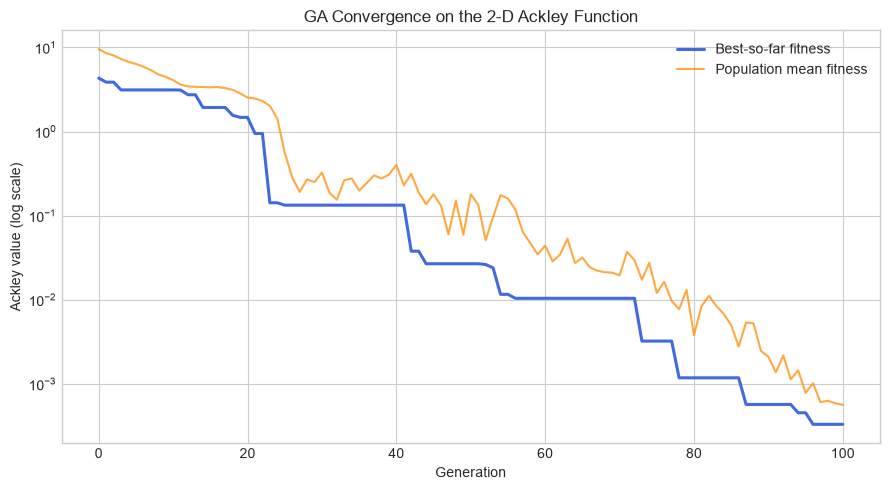

In [13]:
history = result["history"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(
    history["generation"],
    np.maximum(history["best"], 1e-16),
    color="royalblue",
    linewidth=2.2,
    label="Best-so-far fitness",
)
ax.semilogy(
    history["generation"],
    np.maximum(history["mean"], 1e-16),
    color="darkorange",
    alpha=0.75,
    label="Population mean fitness",
)
ax.set_xlabel("Generation")
ax.set_ylabel("Ackley value (log scale)")
ax.set_title("GA Convergence on the 2-D Ackley Function")
ax.legend()
plt.tight_layout()
plt.show()

### Interpreting the convergence curve

- **Fast improvement at the beginning:** roulette-wheel selection and crossover spread useful coordinates through the population.
- **Flat sections:** the population is temporarily exploring similar solutions and no new best solution has appeared.
- **Sudden drops:** mutation or a new crossover combination discovers a better region.
- **Slower improvement near the end:** the algorithm is fine-tuning very close to $(0,0)$ with smaller mutation steps.
- **Mean worse than best:** most population members are not as good as the elite, which preserves some search diversity.

## 7. Search-Space Visualization

The contour plot shows the many local basins of the Ackley function. The white path marks every new best-so-far location recorded by the GA, from the initial best point to the final solution near the red star at the true optimum.

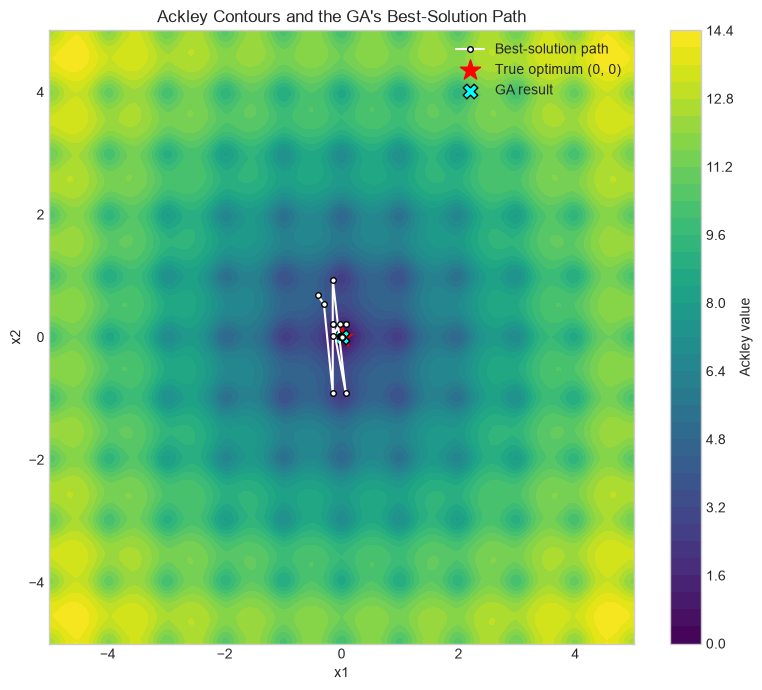

In [14]:
# Build a grid only for visualization; the GA itself does not use this grid.
grid_values = np.linspace(config.lower_bound, config.upper_bound, 350)
X1, X2 = np.meshgrid(grid_values, grid_values)
grid_points = np.stack((X1, X2), axis=-1)
Z = ackley(grid_points)

# Remove repeated best points so the path is easier to see.
best_path = np.column_stack((history["best_x1"], history["best_x2"]))
changed = np.r_[True, np.any(np.diff(best_path, axis=0) != 0, axis=1)]
improvement_path = best_path[changed]

fig, ax = plt.subplots(figsize=(8, 7))
filled = ax.contourf(X1, X2, Z, levels=40, cmap="viridis")
fig.colorbar(filled, ax=ax, label="Ackley value")
ax.plot(
    improvement_path[:, 0],
    improvement_path[:, 1],
    "o-",
    color="white",
    markeredgecolor="black",
    markersize=4,
    linewidth=1.5,
    label="Best-solution path",
)
ax.scatter(0, 0, marker="*", s=230, color="red", label="True optimum (0, 0)")
ax.scatter(
    result["best_solution"][0],
    result["best_solution"][1],
    marker="X",
    s=110,
    color="cyan",
    edgecolor="black",
    label="GA result",
)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Ackley Contours and the GA's Best-Solution Path")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

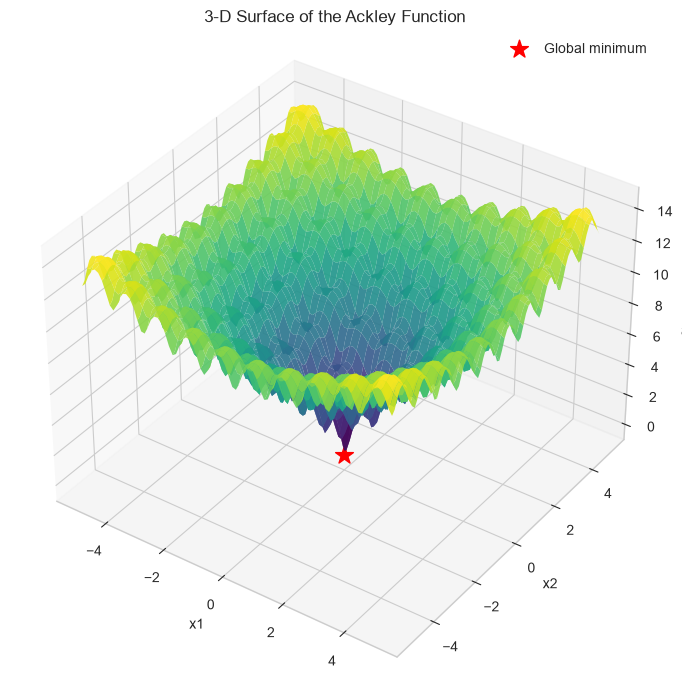

In [15]:
# Optional 3-D view of the objective landscape.
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(
    X1[::4, ::4],
    X2[::4, ::4],
    Z[::4, ::4],
    cmap="viridis",
    linewidth=0,
    antialiased=True,
    alpha=0.9,
)
ax.scatter(0, 0, 0, color="red", marker="*", s=180, label="Global minimum")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("f(x1, x2)")
ax.set_title("3-D Surface of the Ackley Function")
ax.view_init(elev=36, azim=-55)
ax.legend()
plt.tight_layout()
plt.show()

## 8. Reliability Across Multiple Runs

A GA is random, so one successful run is useful but not a complete evaluation. The next cell repeats the same experiment with 10 different seeds and summarizes the final results. Small values across the runs show that the method is reliable, not merely lucky once.

In [16]:
number_of_runs = 10
run_values = []
run_distances = []

print(f"{'Run':>4} {'Seed':>6} {'Best f(x)':>15} {'Distance to (0,0)':>20}")
print("-" * 51)

for run_number in range(number_of_runs):
    run_config = GAConfig(**vars(config))
    run_config.seed = 100 + run_number
    one_result = run_genetic_algorithm(run_config, verbose=False)

    value = one_result["best_value"]
    distance = np.linalg.norm(one_result["best_solution"])
    run_values.append(value)
    run_distances.append(distance)

    print(
        f"{run_number + 1:>4} {run_config.seed:>6} "
        f"{value:>15.10f} {distance:>20.10f}"
    )

run_values = np.asarray(run_values)
run_distances = np.asarray(run_distances)

print("\nSummary over 10 independent runs")
print(f"Best objective value   : {run_values.min():.12f}")
print(f"Mean objective value   : {run_values.mean():.12f}")
print(f"Median objective value : {np.median(run_values):.12f}")
print(f"Standard deviation     : {run_values.std():.12f}")

 Run   Seed       Best f(x)    Distance to (0,0)
---------------------------------------------------
   1    100    0.0003603948         0.0001272663
   2    101    0.0003097056         0.0001093848
   3    102    0.0003160739         0.0001116317
   4    103    0.0001892586         0.0000668709
   5    104    0.0005089764         0.0001796465
   6    105    0.0002554437         0.0000902363
   7    106    0.0001813273         0.0000640702
   8    107    0.0001194538         0.0000422165
   9    108    0.0001904388         0.0000672876
  10    109    0.0007391794         0.0002606995

Summary over 10 independent runs
Best objective value   : 0.000119453783
Mean objective value   : 0.000317025214
Median objective value : 0.000282574640
Standard deviation     : 0.000176233921


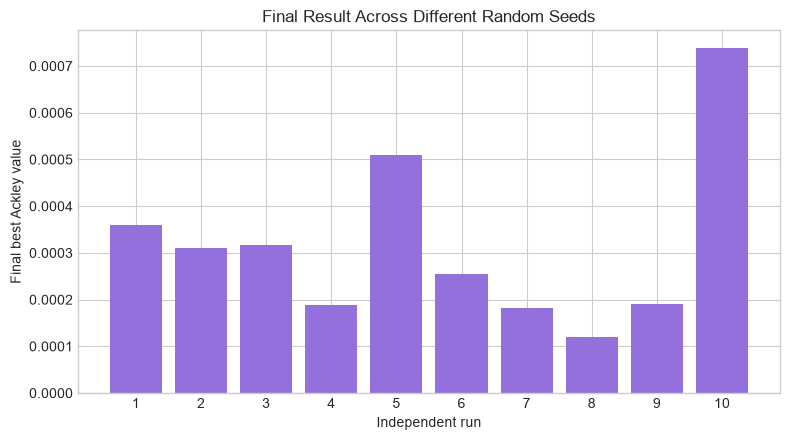

In [17]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(np.arange(1, number_of_runs + 1), run_values, color="mediumpurple")
ax.set_xlabel("Independent run")
ax.set_ylabel("Final best Ackley value")
ax.set_title("Final Result Across Different Random Seeds")
ax.set_xticks(np.arange(1, number_of_runs + 1))
plt.tight_layout()
plt.show()

## 9. Automatic Correctness Checks

These tests verify the most important implementation rules: the known optimum is correct, all chromosomes remain inside the allowed range, population size stays constant, returned values are finite, and elitism makes best-so-far fitness non-increasing.

In [18]:
assert np.isclose(ackley([0, 0]), 0.0, atol=1e-12)
assert result["final_population"].shape == (
    config.population_size,
    config.dimensions,
)
assert np.all(result["final_population"] >= config.lower_bound)
assert np.all(result["final_population"] <= config.upper_bound)
assert np.all(np.isfinite(result["final_values"]))
assert np.all(np.diff(result["history"]["best"]) <= 1e-12)

print("All correctness checks passed.")

All correctness checks passed.


## 10. Conclusion

The Genetic Algorithm successfully minimized the 2-D Ackley function within the required range. The final chromosome is very close to $(0,0)$ and its objective value is very close to the theoretical minimum of zero.

The experiment demonstrates the purpose of each GA component:

- **Roulette-wheel selection** gives better chromosomes a greater chance to reproduce.
- **One-point crossover** combines $x_1$ from one parent with $x_2$ from another.
- **Gaussian mutation** introduces new values and helps escape local minima.
- **Clipping** guarantees that mutated values stay in $[-5,5]$.
- **Elitism** ensures that the best solution found is never lost.
- **Adaptive mutation size** supports wide exploration early and precise improvement later.
